# 1. Import Libraries

In [76]:
# Standard library

import re
import os
import random
import copy
from collections import Counter


# Third-party libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Scikit-learn

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# XGBoost

from xgboost import XGBClassifier


# PyTorch

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Hugging Face Datasets

import datasets
from datasets import Dataset
datasets.config.TORCHVISION_AVAILABLE = False
# import sys
# # Prevent datasets from trying to use torchvision
# sys.modules["torchvision"] = None


# Hugging Face Transformers

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    logging,
    Trainer,
    TrainingArguments,
)

# NLTK

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 2. Load Dataset

In [82]:
# Read data
df = pd.read_csv("Tweets.csv")

# Check columns
print(df.columns)
print(df.head())

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        Na

# 3. Exploratory Data Analysis

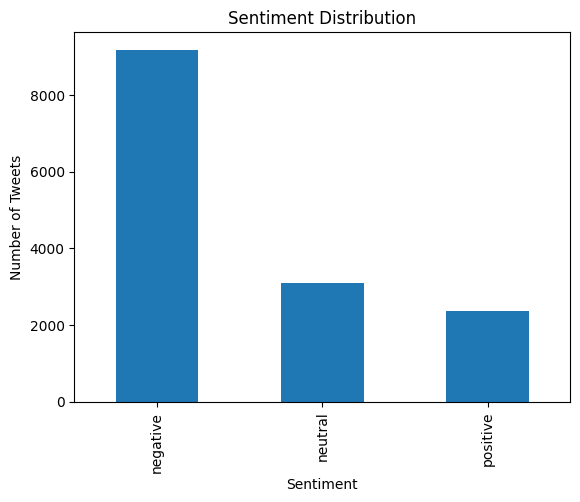

In [67]:
# Sentiment distribution
df["airline_sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

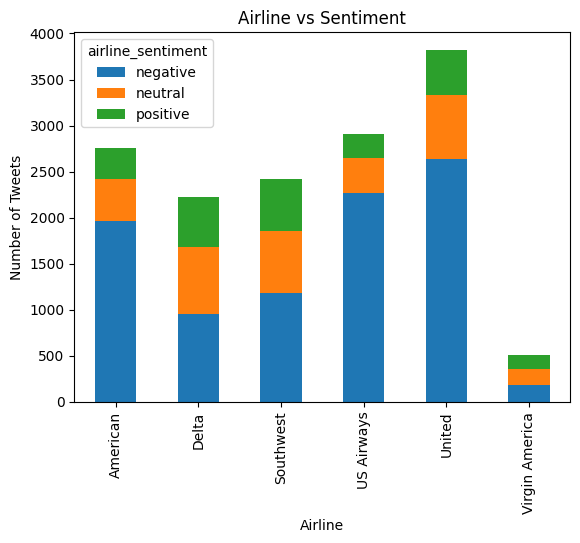

In [68]:
# Airline vs. sentiment stacked bar chart
sentiment_by_airline = pd.crosstab(
    df["airline"],
    df["airline_sentiment"]
)

sentiment_by_airline.plot(kind="bar", stacked=True)
plt.title("Airline vs Sentiment")
plt.xlabel("Airline")
plt.ylabel("Number of Tweets")
plt.show()

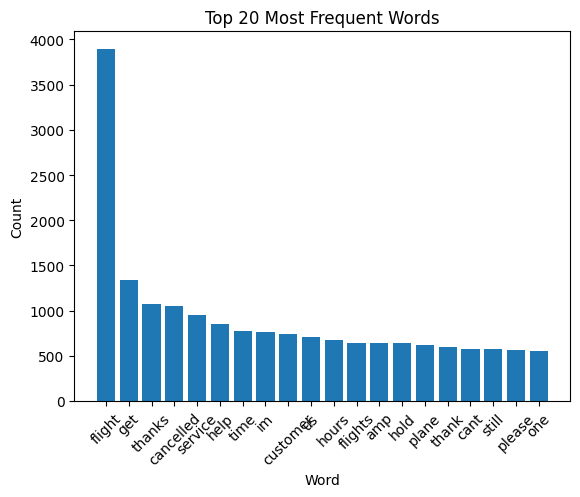

In [69]:
# Top 20 frequent words
text = " ".join(df["text"].dropna()).lower()

text = re.sub(r"http\S+", "", text)
text = re.sub(r"@\w+", "", text)
text = re.sub(r"[^a-z\s]", "", text)

words = text.split()

stop_words = set(stopwords.words("english"))

words = [word for word in words if word not in stop_words]

word_counts = Counter(words).most_common(20)

words_df = pd.DataFrame(word_counts, columns=["word", "count"])

plt.bar(words_df["word"], words_df["count"])
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

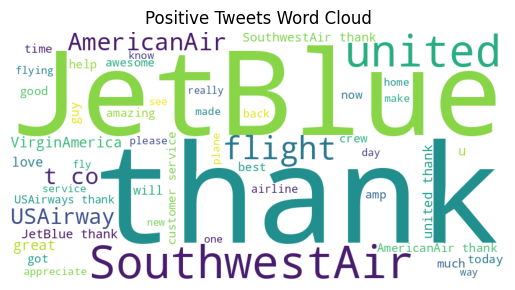

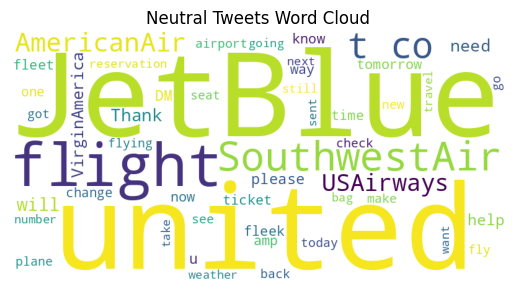

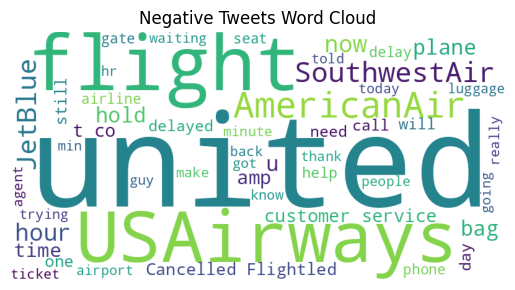

In [70]:
# Prepare Text for Word Cloud Visualization
positive_text = " ".join(df[df["airline_sentiment"] == "positive"]["text"].dropna())
neutral_text = " ".join(df[df["airline_sentiment"] == "neutral"]["text"].dropna())
negative_text = " ".join(df[df["airline_sentiment"] == "negative"]["text"].dropna())

# Word cloud for positive tweets
wordcloud = WordCloud(width=800, height=400, background_color="white", max_words=50).generate(positive_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Tweets Word Cloud")
plt.show()

# Word cloud for neutral tweets
wordcloud = WordCloud(width=800, height=400, background_color="white", max_words=50).generate(neutral_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Neutral Tweets Word Cloud")
plt.show()

# Word cloud for negative tweets
wordcloud = WordCloud(width=800, height=400, background_color="white", max_words=50).generate(negative_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Tweets Word Cloud")
plt.show()

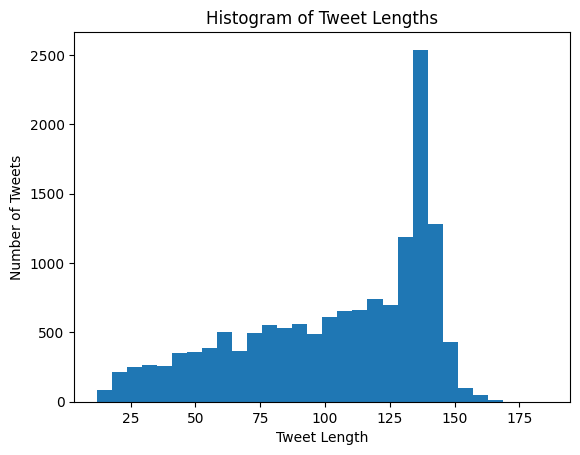

In [ ]:
# Histogram of tweet lengths
df["tweet_length"] = df["text"].apply(len)

plt.hist(df["tweet_length"], bins=30)
plt.title("Histogram of Tweet Lengths")
plt.xlabel("Tweet Length")
plt.ylabel("Number of Tweets")
plt.show()

# 4. Text Processing

In [86]:
# Clean tweet text
df = df.dropna(subset=["text"])
df_original = df.copy()

df["processed_text"] = (
    df["text"]
    .str.lower()                                        # lowercase
    .str.replace(r"http\S+", "", regex=True)            # remove URLs
    .str.replace(r"@\w+", "", regex=True)               # remove @mentions
    .str.replace("#", "", regex=False)                  # remove # but keep the word
    .str.replace(r"[^\w\s]", "", regex=True)            # remove punctuation
    .str.replace(r"\d+", "", regex=True)                # remove numbers
    .str.replace(r"\s+", " ", regex=True)               # remove extra spaces
    .str.strip()                                        # trim spaces
)

# Initialize the WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df["processed_text"] = df["processed_text"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word, pos="v")
        for word in text.split()
    )
)


# 5. Feature Engineering: CountVectorizer vs. TF-IDF

In [72]:
# Vectorizing
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["airline_sentiment"])

vectorizers = {
    "CountVectorizer": CountVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.95
    ),
    "TF-IDF": TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.95
    )
}

# Evaluate with cross-validation
scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision_macro",
    "Recall": "recall_macro",
    "F1 Score": "f1_macro"
}

results = []

for name, vectorizer in vectorizers.items():
    pipeline = Pipeline([
        ("vectorizer", vectorizer),
        ("classifier", LogisticRegression(max_iter=1000))
    ])

    scores = cross_validate(
        pipeline,
        df["processed_text"],
        y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Feature Extraction": name,
        "Accuracy": scores["test_Accuracy"].mean(),
        "Macro Precision": scores["test_Precision"].mean(),
        "Macro Recall": scores["test_Recall"].mean(),
        "Macro F1 Score": scores["test_F1 Score"].mean()
    })

comparison_cv = pd.DataFrame(results).round(4)
display(comparison_cv)

,Feature Extraction,Accuracy,Macro Precision,Macro Recall,Macro F1 Score
0,CountVectorizer,0.7875,0.7385,0.7190,0.7271
1,TF-IDF,0.7915,0.7741,0.6797,0.7133


# 6. Baseline Models

In [ ]:
# Compare classifers with CountVectorizer feature engineering
count_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

# Train/test split
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    stratify=df["airline_sentiment"],
    random_state=42
)

X_train_text = df.loc[train_idx, "processed_text"]
X_test_text = df.loc[test_idx, "processed_text"]

y_train = label_encoder.transform(
    df.loc[train_idx, "airline_sentiment"]
)
y_test = label_encoder.transform(
    df.loc[test_idx, "airline_sentiment"]
)

X_train = count_vectorizer.fit_transform(X_train_text)
X_test = count_vectorizer.transform(X_test_text)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    )
}

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=scoring
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_Accuracy"].mean(),
        "Macro Precision": scores["test_Precision"].mean(),
        "Macro Recall": scores["test_Recall"].mean(),
        "Macro F1 Score": scores["test_F1 Score"].mean()
    })

comparison = pd.DataFrame(results).round(4)

print(comparison)

                 Model  Accuracy  Macro Precision  Macro Recall  \
0  Logistic Regression    0.7929           0.7434        0.7274   
1          Naive Bayes    0.7687           0.7075        0.7162   
2           Linear SVM    0.7623           0.7010        0.7005   
3        Random Forest    0.7687           0.7485        0.6360   
4              XGBoost    0.7920           0.7571        0.7015   

   Macro F1 Score  
0          0.7349  
1          0.7112  
2          0.7005  
3          0.6709  
4          0.7244  


# 7. Error Analysis (Best Baseline Model)

In [ ]:
# Error Analysis with Logistic Regression
y_pred = cross_val_predict(
    LinearSVC(),
    X_test,
    y_test,
    cv=5
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Neutral", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Neutral", "Predicted Positive"]
)

display(cm_df)

# Classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Neutral", "Positive"]
))

# Show misclassified examples
results = pd.DataFrame({
    "Tweet":  df.loc[test_idx, "text"].values,
    "Actual": y_test,
    "Predicted": y_pred
})

errors = results[results["Actual"] != results["Predicted"]]

errors.head(10)

,Predicted Negative,Predicted Neutral,Predicted Positive
Actual Negative,1522,222,91
Actual Neutral,209,355,56
Actual Positive,115,84,274


              precision    recall  f1-score   support

    Negative       0.82      0.83      0.83      1835
     Neutral       0.54      0.57      0.55       620
    Positive       0.65      0.58      0.61       473

    accuracy                           0.73      2928
   macro avg       0.67      0.66      0.66      2928
weighted avg       0.74      0.73      0.73      2928



,Tweet,Actual,Predicted
1,would you say a delay be more likely thank so ...,2,0
9,when will the flight resume i don see it in th...,0,1
17,too long for character,0,1
18,well i do miss it but gate agents have rebooke...,2,0
22,my flight be leave las vegas at pm arrive at c...,0,1
27,be there any way you could put me up in a hote...,0,1
32,get dupe w a connection on st flight sneaky no...,0,1
33,such a bummer but i understand its a business ...,1,0
39,she be travel with me the one that get miscomm...,0,1
44,do you have bereavement discount on airfare as...,1,0


# 8. Text Encoding for the PyTorch Model

In [ ]:
# Tokenize each tweet
df["tokens"] = df["processed_text"].str.split()

# Build vocabulary
word_counts = Counter()

for tokens in df["tokens"]:
    word_counts.update(tokens)

# Reserve two IDs
vocab = {"<PAD>": 0, "<UNK>": 1}

for word, count in word_counts.items():
    if count >= 2:   # ignore very rare words
        vocab[word] = len(vocab)

# Convert tokens to word IDs
def tokens_to_ids(tokens, vocab):
    return [vocab.get(token, vocab["<UNK>"]) for token in tokens]

df["ids"] = df["tokens"].apply(lambda tokens: tokens_to_ids(tokens, vocab))

# Pad/truncate to fixed length
MAX_LEN = 40

def pad_or_truncate(ids, max_len = MAX_LEN):
    if len(ids) > max_len:
        return ids[:max_len]
    return ids + [vocab["<PAD>"]] * (max_len - len(ids))

df["ids"] = df["ids"].apply(pad_or_truncate)

# 9. PyTorch Baseline Model

In [ ]:
# Build PyTorch Classifier
class TweetSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes, pad_idx):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        self.fc = nn.Sequential(
            nn.Linear(embedding_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        embedded = self.embedding(x)

        mask = (x != vocab["<PAD>"]).unsqueeze(-1)
        embedded = embedded * mask

        summed = embedded.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1)

        pooled = summed / lengths

        logits = self.fc(pooled)
        return logits

# Create labels
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["airline_sentiment"].map(label_map)

# Create tensors
X = torch.tensor(df["ids"].tolist(), dtype=torch.long)
y = torch.tensor(df["label"].tolist(), dtype=torch.long)


# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


# Create a dataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Create a dataLoader
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Create model
model = TweetSentimentModel(
    vocab_size=len(vocab),
    embedding_dim=200,
    num_classes=3,
    pad_idx=vocab["<PAD>"]
)

# Use class weights
classes = np.array([0, 1, 2])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.numpy()
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

loss_fn = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Training loop with early stopping
best_val_f1 = 0
best_model_state = None
epochs_without_improvement = 0
patience = 8
epochs = 50

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_train_loss:.4f}")

    # validation
    model.eval()
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())

    val_f1 = f1_score(val_labels, val_preds, average="macro")

    print(
        f"Epoch {epoch+1}, "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Macro F1: {val_f1:.4f}"
    )

    # early stopping logic
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# load best model
model.load_state_dict(best_model_state)

# Evaluation
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=["negative", "neutral", "positive"]
))

Epoch 1, Loss: 1.0219
Epoch 1, Train Loss: 1.0219, Val Macro F1: 0.5549
Epoch 2, Loss: 0.9169
Epoch 2, Train Loss: 0.9169, Val Macro F1: 0.6138
Epoch 3, Loss: 0.8187
Epoch 3, Train Loss: 0.8187, Val Macro F1: 0.6297
Epoch 4, Loss: 0.7402
Epoch 4, Train Loss: 0.7402, Val Macro F1: 0.6433
Epoch 5, Loss: 0.6753
Epoch 5, Train Loss: 0.6753, Val Macro F1: 0.6608
Epoch 6, Loss: 0.6369
Epoch 6, Train Loss: 0.6369, Val Macro F1: 0.6726
Epoch 7, Loss: 0.5914
Epoch 7, Train Loss: 0.5914, Val Macro F1: 0.6814
Epoch 8, Loss: 0.5505
Epoch 8, Train Loss: 0.5505, Val Macro F1: 0.6927
Epoch 9, Loss: 0.5196
Epoch 9, Train Loss: 0.5196, Val Macro F1: 0.6949
Epoch 10, Loss: 0.4953
Epoch 10, Train Loss: 0.4953, Val Macro F1: 0.7057
Epoch 11, Loss: 0.4746
Epoch 11, Train Loss: 0.4746, Val Macro F1: 0.7079
Epoch 12, Loss: 0.4507
Epoch 12, Train Loss: 0.4507, Val Macro F1: 0.7092
Epoch 13, Loss: 0.4301
Epoch 13, Train Loss: 0.4301, Val Macro F1: 0.7127
Epoch 14, Loss: 0.4129
Epoch 14, Train Loss: 0.4129, Val

# 10. Preparing Data for BERT

In [87]:
# Prepare labels (BERT)
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["airline_sentiment"].map(label_map)

# Create training, validation and test sets
train_df, temp_df = train_test_split(
    df_original[["text", "label"]],
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

# Convert to Hugging Face dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

# Load tokenizer
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize tweets
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/10248 [00:00<?, ? examples/s]

Map:   0%|          | 0/2196 [00:00<?, ? examples/s]

Map:   0%|          | 0/2196 [00:00<?, ? examples/s]

# 11. BERT Fine-Tuning

In [88]:
# Set format for PyTorch
train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Create BERT classifier
logging.set_verbosity_error()

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Training settings
training_args = TrainingArguments(
    output_dir="./bert_flight_sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

# Train
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

{'loss': '0.5126', 'grad_norm': '10.41', 'learning_rate': '1.481e-05', 'epoch': '0.78'}
{'eval_loss': '0.4605', 'eval_runtime': '15.92', 'eval_samples_per_second': '137.9', 'eval_steps_per_second': '8.667', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.3237', 'grad_norm': '1.728', 'learning_rate': '9.61e-06', 'epoch': '1.56'}
{'eval_loss': '0.4463', 'eval_runtime': '15.94', 'eval_samples_per_second': '137.8', 'eval_steps_per_second': '8.66', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2541', 'grad_norm': '15.9', 'learning_rate': '4.41e-06', 'epoch': '2.34'}
{'eval_loss': '0.5385', 'eval_runtime': '15.97', 'eval_samples_per_second': '137.5', 'eval_steps_per_second': '8.641', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '725.6', 'train_samples_per_second': '42.37', 'train_steps_per_second': '2.65', 'train_loss': '0.3237', 'epoch': '3'}


TrainOutput(global_step=1923, training_loss=0.32374445398958535, metrics={'train_runtime': 725.6147, 'train_samples_per_second': 42.37, 'train_steps_per_second': 2.65, 'train_loss': 0.32374445398958535, 'epoch': 3.0})

# 12. BERT Model Evaluation

In [62]:
# Evaluate on test set
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
y_pred = np.argmax(logits, axis=1)
y_true = predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=["negative", "neutral", "positive"]
))

              precision    recall  f1-score   support

    negative       0.91      0.87      0.89      1377
     neutral       0.67      0.63      0.65       465
    positive       0.69      0.87      0.77       354

    accuracy                           0.82      2196
   macro avg       0.76      0.79      0.77      2196
weighted avg       0.82      0.82      0.82      2196



# 13. Save the BERT Model

In [63]:
# Save the model
PROJECT_DIR = "./airline-sentiment-api"
MODEL_DIR = f"{PROJECT_DIR}/artifacts/bert_model"

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print(f"Model and tokenizer saved to: {MODEL_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: ./airline-sentiment-api/artifacts/bert_model
